Note: you may need to restart the kernel to use updated packages.
✅ Loaded 15 documents


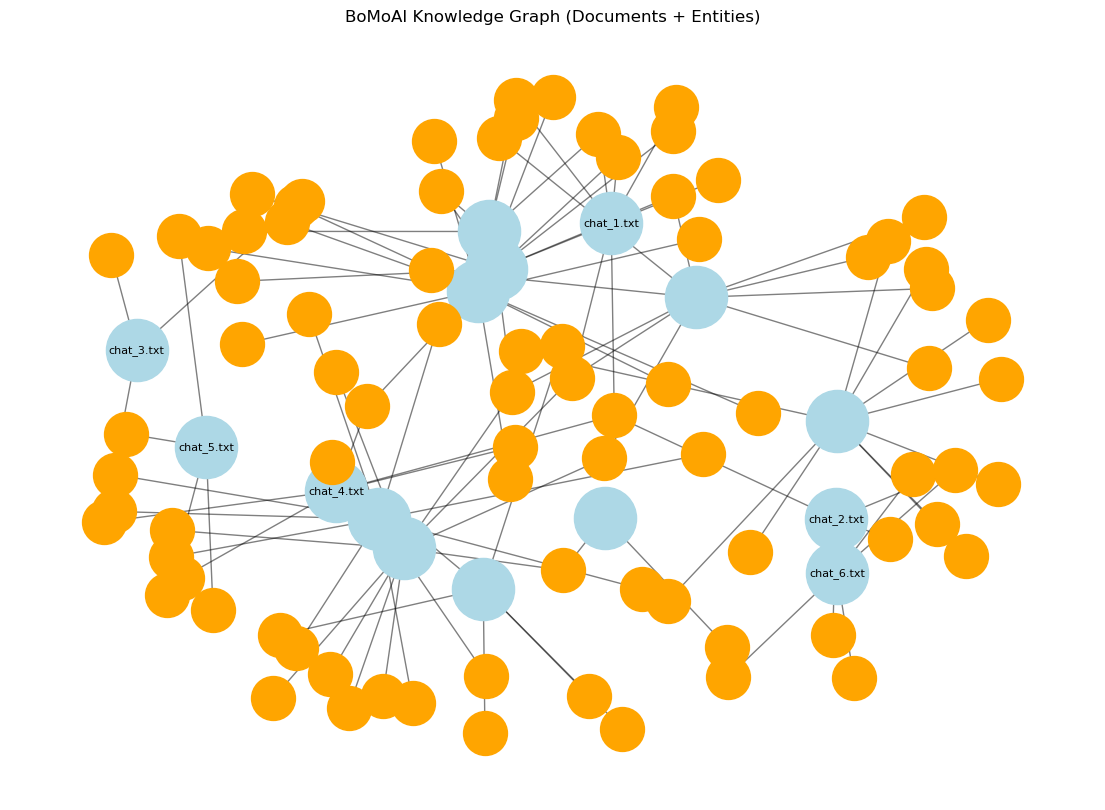


=== SAMPLE ENTITY EXTRACTION ===

📄 chat_1.txt
['なっ', 'AI', '遅れ', 'てる', 'まだ', 'どう']

📄 chat_2.txt
['ルール', 'まだ', 'ない', '新しい']

📄 chat_3.txt
['ミーティング', '今日', 'ある']

📄 chat_4.txt
['っぽい', 'データ', 'まだ', 'ある', '問題']

📄 chat_5.txt
['ウド', 'クラ', 'らしい', '使う']

=== DETECTED GAPS ===
('chat_1.txt', 'MISSING_DATE')
('chat_1.txt', 'NO_REGULATION_REFERENCE')
('chat_2.txt', 'NO_REGULATION_REFERENCE')
('chat_3.txt', 'NO_REGULATION_REFERENCE')
('chat_4.txt', 'NO_REGULATION_REFERENCE')
('chat_5.txt', 'NO_REGULATION_REFERENCE')


In [5]:
# Install required libraries
%pip install networkx matplotlib janome pandas --quiet

import os
import json
import networkx as nx
import matplotlib.pyplot as plt
from janome.tokenizer import Tokenizer
import pandas as pd
import re



folder_path = "D:/Bomo AI/data"   


# Tokenizer (Japanese)

tokenizer = Tokenizer()


# Helper: Detect Language

def is_japanese(text):
    return bool(re.search(r'[ぁ-んァ-ン一-龥]', text))


# Helper: Extract Keywords (Simple NLP)
def extract_keywords(text):
    words = []
    
    if is_japanese(text):
        tokens = tokenizer.tokenize(text)
        words = [t.surface for t in tokens if len(t.surface) > 1]
    else:
        words = re.findall(r'\b[A-Za-z]{3,}\b', text)
    
    return list(set(words))[:10]  # limit


#  Load ALL files (txt + json)

documents = []

for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    
    try:
        # TXT files
        if filename.endswith(".txt"):
            with open(file_path, "r", encoding="utf-8") as f:
                content = f.read()
        
        # JSON files
        elif filename.endswith(".json"):
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
                content = json.dumps(data, ensure_ascii=False)
        
        else:
            continue
        
        documents.append({
            "file": filename,
            "content": content
        })
    
    except Exception as e:
        print(f"Error reading {filename}: {e}")

print(f"✅ Loaded {len(documents)} documents")


# 🧠 Build Knowledge Graph

G = nx.Graph()

for doc in documents:
    file_node = doc["file"]
    content = doc["content"]
    
    # Add document node
    G.add_node(file_node, type="document")
    
    # Extract keywords/entities
    keywords = extract_keywords(content)
    
    for kw in keywords:
        # Add entity node
        G.add_node(kw, type="entity")
        
        # Connect doc -> entity
        G.add_edge(file_node, kw)


# GAP DETECTION

gaps = []

for doc in documents:
    content = doc["content"]
    
    # Gap 1: AI mentioned but no date
    if "AI" in content or "AIシステム" in content:
        if not re.search(r'\d{4}', content):
            gaps.append((doc["file"], "MISSING_DATE"))
    
    # Gap 2: Regulation missing
    if "規制" not in content and "regulation" not in content.lower():
        gaps.append((doc["file"], "NO_REGULATION_REFERENCE"))


# Visualization

plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, k=0.5)

# Separate nodes
doc_nodes = [n for n, d in G.nodes(data=True) if d['type']=="document"]
entity_nodes = [n for n, d in G.nodes(data=True) if d['type']=="entity"]

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=doc_nodes, node_color='lightblue', node_size=2000)
nx.draw_networkx_nodes(G, pos, nodelist=entity_nodes, node_color='orange', node_size=1000)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.5)

# Labels (only few to avoid clutter)
labels = {n:n for n in doc_nodes[:6]}  # limit
nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title("BoMoAI Knowledge Graph (Documents + Entities)")
plt.axis('off')
plt.show()


#  PRINT RESULTS

print("\n=== SAMPLE ENTITY EXTRACTION ===")
for doc in documents[:5]:
    print(f"\n📄 {doc['file']}")
    print(extract_keywords(doc["content"]))

print("\n=== DETECTED GAPS ===")
for g in gaps[:6]:
    print(g)